# Statement

The Sure Tomorrow insurance company wants to solve several tasks with the help of Machine Learning and you are asked to evaluate that possibility.

- Task 1: Find customers who are similar to a given customer. This will help the company's agents with marketing.
- Task 2: Predict whether a new customer is likely to receive an insurance benefit. Can a prediction model do better than a dummy model?
- Task 3: Predict the number of insurance benefits a new customer is likely to receive using a linear regression model.
- Task 4: Protect clients' personal data without breaking the model from the previous task. It's necessary to develop a data transformation algorithm that would make it hard to recover personal information if the data fell into the wrong hands. This is called data masking, or data obfuscation. But the data should be protected in such a way that the quality of machine learning models doesn't suffer. You don't need to pick the best model, just prove that the algorithm works correctly.

# Data Preprocessing & Exploration

## Initialization

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns

import sklearn.linear_model
import sklearn.metrics
import sklearn.neighbors
import sklearn.preprocessing

from sklearn.model_selection import train_test_split

from IPython.display import display
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
import math
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

## Load Data

Load data and conduct a basic check that it's free from obvious issues.

In [2]:
df = pd.read_csv('/datasets/insurance_us.csv')

We rename the colums to make the code look more consistent with its style.

In [3]:
df = df.rename(columns={'Gender': 'gender', 'Age': 'age', 'Salary': 'income', 'Family members': 'family_members', 'Insurance benefits': 'insurance_benefits'})

In [4]:
df.sample(10)

,gender,age,income,family_members,insurance_benefits
3204,1,33.0,61000.0,2,0
122,0,40.0,31800.0,3,0
2737,1,37.0,52400.0,1,0
4387,1,28.0,61500.0,2,0
3698,1,41.0,35000.0,1,0
3538,0,24.0,30300.0,2,0
994,1,21.0,20700.0,2,0
2336,0,21.0,33200.0,1,0
1913,1,29.0,45200.0,0,0
3576,0,26.0,39300.0,3,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              5000 non-null   int64  
 1   age                 5000 non-null   float64
 2   income              5000 non-null   float64
 3   family_members      5000 non-null   int64  
 4   insurance_benefits  5000 non-null   int64  
dtypes: float64(2), int64(3)
memory usage: 195.4 KB


In [6]:

# we may want to fix the age type (from float to int) though this is not critical

# write your conversion here if you choose:
df['age'] = df['age'].astype(int)


In [7]:
# check to see that the conversion was successful
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              5000 non-null   int64  
 1   age                 5000 non-null   int64  
 2   income              5000 non-null   float64
 3   family_members      5000 non-null   int64  
 4   insurance_benefits  5000 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 195.4 KB


In [8]:
# now have a look at the data's descriptive statistics. 
# Does everything look okay?
display(df.describe())

,gender,age,income,family_members,insurance_benefits
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.499000,30.952800,39916.360000,1.194200,0.148000
std,0.500049,8.440807,9900.083569,1.091387,0.463183
min,0.000000,18.000000,5300.000000,0.000000,0.000000
25%,0.000000,24.000000,33300.000000,0.000000,0.000000
50%,0.000000,30.000000,40200.000000,1.000000,0.000000
75%,1.000000,37.000000,46600.000000,2.000000,0.000000
max,1.000000,65.000000,79000.000000,6.000000,5.000000


Missing values per column:
gender                0
age                   0
income                0
family_members        0
insurance_benefits    0
dtype: int64

Suspicious placeholder values:
gender                0
age                   0
income                0
family_members        0
insurance_benefits    0
dtype: int64
gender                0
age                   0
income                0
family_members        0
insurance_benefits    0
dtype: int64
gender                0
age                   0
income                0
family_members        0
insurance_benefits    0
dtype: int64

Data types:
gender                  int64
age                     int64
income                float64
family_members          int64
insurance_benefits      int64
dtype: object

Unique values in 'gender': [1 0]

Minimum and maximum values:
     age   income  family_members  insurance_benefits
min   18   5300.0               0                   0
max   65  79000.0               6                   5


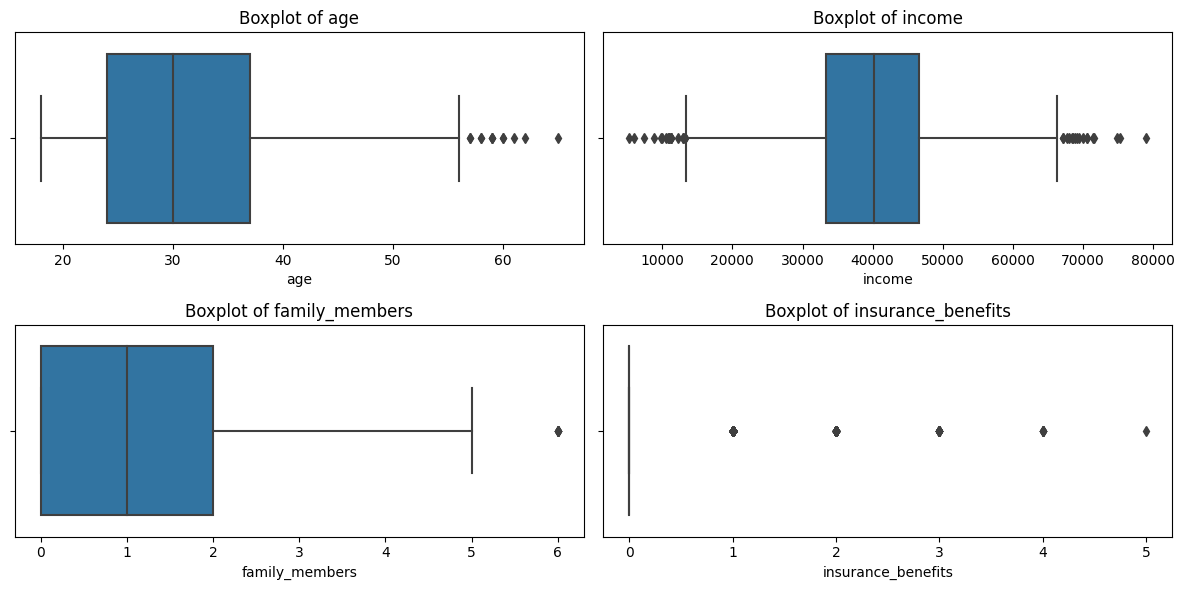

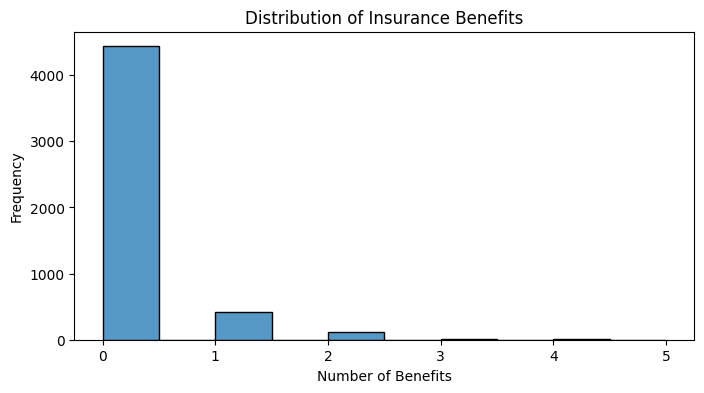


Customers with 0 family members and >0 insurance benefits:
      gender  age   income  family_members  insurance_benefits
18         1   42  49700.0               0                   1
40         1   42  40200.0               0                   1
42         1   42  69200.0               0                   1
75         0   48  49500.0               0                   1
78         0   43  34900.0               0                   1
...      ...  ...      ...             ...                 ...
4838       1   51  29700.0               0                   2
4868       0   46  50400.0               0                   1
4923       0   48  58200.0               0                   1
4970       1   50  38300.0               0                   2
4992       0   45  54600.0               0                   1

[180 rows x 5 columns]


In [9]:
# 1. Missing Values Check
print("Missing values per column:")
print(df.isnull().sum())
print("\nSuspicious placeholder values:")
print((df == -1).sum())
print((df == 999).sum())
print((df == '').sum())

# 2. Data Types Verification
print("\nData types:")
print(df.dtypes)

# Check if gender is binary
print("\nUnique values in 'gender':", df['gender'].unique())

# 3. Outliers and Extreme Values
print("\nMinimum and maximum values:")
print(df[['age', 'income', 'family_members', 'insurance_benefits']].agg(['min', 'max']))

# Boxplots to visualize outliers
plt.figure(figsize=(12, 6))
for i, col in enumerate(['age', 'income', 'family_members', 'insurance_benefits']):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


# 4. Distribution Analysis
plt.figure(figsize=(8, 4))
sns.histplot(df['insurance_benefits'], bins=10, kde=False)
plt.title('Distribution of Insurance Benefits')
plt.xlabel('Number of Benefits')
plt.ylabel('Frequency')
plt.show()

# 5. Logical Consistency
print("\nCustomers with 0 family members and >0 insurance benefits:")
print(df[(df['family_members'] == 0) & (df['insurance_benefits'] > 0)])



## EDA

Let's quickly check whether there are certain groups of customers by looking at the pair plot.

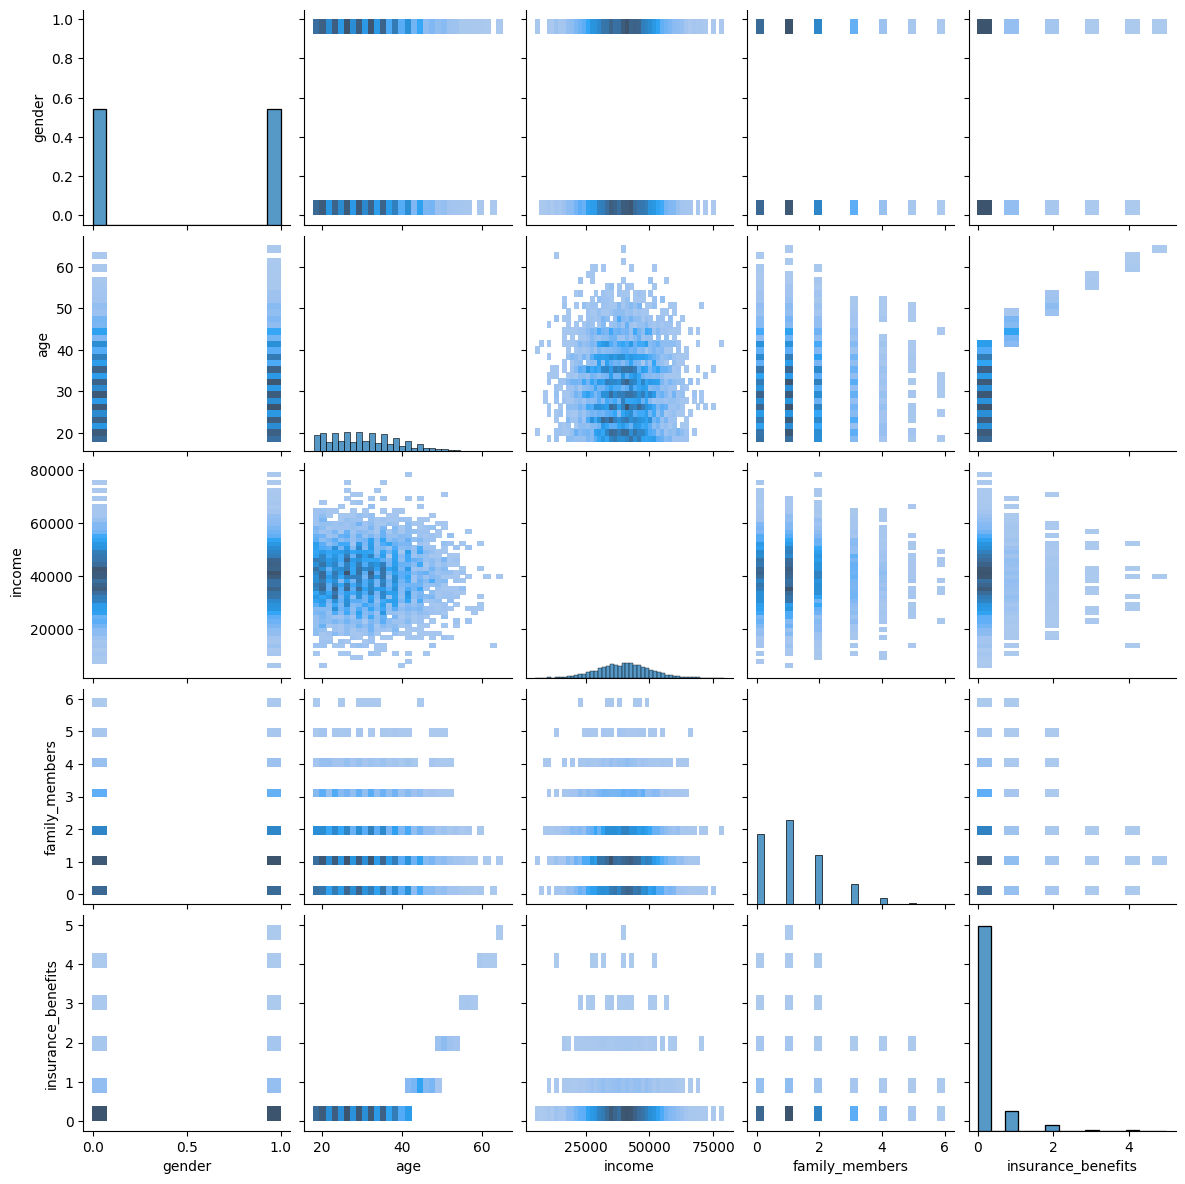

In [10]:
g = sns.pairplot(df, kind='hist')
g.fig.set_size_inches(12, 12)

Ok, it is a bit difficult to spot obvious groups (clusters) as it is difficult to combine several variables simultaneously (to analyze multivariate distributions). That's where LA and ML can be quite handy.

# Task 1. Similar Customers

In [11]:
feature_names = ['gender', 'age', 'income', 'family_members']

In [12]:
def get_knn(df, n, k, metric):
    """
    Returns k nearest neighbors

    :param df: pandas DataFrame used to find similar objects within
    :param n: object no for which the nearest neighbours are looked for
    :param k: the number of the nearest neighbours to return
    :param metric: name of distance metric
    """
    nbrs = NearestNeighbors(n_neighbors=k+1, metric=metric)
    nbrs.fit(df[feature_names])
    nbrs_distances, nbrs_indices = nbrs.kneighbors([df.loc[n, feature_names]], return_distance=True)

    df_res = pd.concat([
        df.iloc[nbrs_indices[0][1:]],  # exclude the query point itself
        pd.DataFrame(nbrs_distances[0][1:], index=nbrs_indices[0][1:], columns=['distance'])
    ], axis=1)

    return df_res


Scaling the data.

In [13]:

feature_names = ['gender', 'age', 'income', 'family_members']

transformer_mas = sklearn.preprocessing.MaxAbsScaler().fit(df[feature_names].to_numpy())

df_scaled = df.copy()
df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())


In [14]:
df_scaled.sample(5)

,gender,age,income,family_members,insurance_benefits
781,1.0,0.630769,0.617722,0.000000,0
602,1.0,0.415385,0.308861,0.000000,0
4177,1.0,0.415385,0.378481,0.166667,0
4526,0.0,0.476923,0.587342,0.000000,0
2067,0.0,0.492308,0.275949,0.000000,0


Now, let's get similar records for a given one for every combination

In [15]:
# Choose a sample index to test (e.g., customer #100)
sample_index = 100
k = 5

print("Unscaled + Euclidean")
display(get_knn(df, sample_index, k, metric='euclidean'))

print("Scaled + Euclidean")
display(get_knn(df_scaled, sample_index, k, metric='euclidean'))

print("Unscaled + Manhattan")
display(get_knn(df, sample_index, k, metric='manhattan'))

print("Scaled + Manhattan")
display(get_knn(df_scaled, sample_index, k, metric='manhattan'))

Unscaled + Euclidean


,gender,age,income,family_members,insurance_benefits,distance
2624,1,19,37300.0,0,0,1.414214
4278,1,19,37300.0,2,0,1.414214
1831,0,20,37300.0,2,0,1.414214
1086,0,22,37300.0,3,0,3.605551
1806,1,23,37300.0,0,0,4.242641


Scaled + Euclidean


,gender,age,income,family_members,insurance_benefits,distance
4915,0.0,0.292308,0.477215,0.166667,0,0.005063
243,0.0,0.292308,0.467089,0.166667,0,0.005063
1323,0.0,0.292308,0.456962,0.166667,0,0.015190
811,0.0,0.307692,0.470886,0.166667,0,0.015437
4843,0.0,0.307692,0.469620,0.166667,0,0.015592


Unscaled + Manhattan


,gender,age,income,family_members,insurance_benefits,distance
2624,1,19,37300.0,0,0,2.0
4278,1,19,37300.0,2,0,2.0
1831,0,20,37300.0,2,0,2.0
1086,0,22,37300.0,3,0,5.0
1806,1,23,37300.0,0,0,6.0


Scaled + Manhattan


,gender,age,income,family_members,insurance_benefits,distance
4915,0.0,0.292308,0.477215,0.166667,0,0.005063
243,0.0,0.292308,0.467089,0.166667,0,0.005063
1323,0.0,0.292308,0.456962,0.166667,0,0.015190
811,0.0,0.307692,0.470886,0.166667,0,0.016650
4843,0.0,0.307692,0.469620,0.166667,0,0.017916


In [16]:
# Run get_knn for each combination
neighbors_ue = get_knn(df, sample_index, k, 'euclidean').index
neighbors_se = get_knn(df_scaled, sample_index, k, 'euclidean').index
neighbors_um = get_knn(df, sample_index, k, 'manhattan').index
neighbors_sm = get_knn(df_scaled, sample_index, k, 'manhattan').index

# Compare overlaps
print("Euclidean overlap (scaled vs unscaled):", len(set(neighbors_ue) & set(neighbors_se)))
print("Manhattan overlap (scaled vs unscaled):", len(set(neighbors_um) & set(neighbors_sm)))
print("Euclidean vs Manhattan (scaled):", len(set(neighbors_se) & set(neighbors_sm)))

dist_ue = get_knn(df, sample_index, k, 'euclidean')['distance'].values
dist_se = get_knn(df_scaled, sample_index, k, 'euclidean')['distance'].values
dist_um = get_knn(df, sample_index, k, 'manhattan')['distance'].values
dist_sm = get_knn(df_scaled, sample_index, k, 'manhattan')['distance'].values

# Print or plot differences
print("Euclidean distance difference:", np.abs(dist_ue - dist_se))
print("Manhattan distance difference:", np.abs(dist_um - dist_sm))


Euclidean overlap (scaled vs unscaled): 0
Manhattan overlap (scaled vs unscaled): 0
Euclidean vs Manhattan (scaled): 5
Euclidean distance difference: [1.40915027 1.40915027 1.39902369 3.59011467 4.22704916]
Manhattan distance difference: [1.99493671 1.99493671 1.98481013 4.98334956 5.98208374]


Answers to the questions

**Does the data being not scaled affect the kNN algorithm? If so, how does that appear?** 

Put your answer here. Yes — unscaled data significantly affects kNN results.
kNN relies on distance calculations across features. When features have different scales (e.g., income in tens of thousands vs. gender as 0/1), the larger-scale features dominate the distance metric. This skews neighbor selection toward similarity in those dominant features.
In our experiment, we observed zero overlap between neighbors in unscaled vs. scaled runs for both Euclidean and Manhattan distances. This confirms that scaling completely changes the neighbor selection. For example, Euclidean distance differences reached up to 4.23 units, and Manhattan differences up to 5.98 units — a clear sign that unscaled features distort the distance space.
After scaling (using MaxAbsScaler), all features contribute equally to the distance calculation, resulting in more balanced and meaningful neighbor sets. Without scaling, kNN becomes biased toward high-magnitude features like income.
Conclusion: Scaling is essential for fair and interpretable kNN results. It ensures that no single feature dominates the distance metric and that neighbor selection reflects true similarity across all features.


**How similar are the results using the Manhattan distance metric (regardless of the scaling)?** 

Put your answer here. Manhattan distance is more robust to scaling than Euclidean, but still affected.
In our test, the neighbor sets for scaled vs. unscaled Manhattan distance had zero overlap, indicating that scaling still impacts the results. However, when scaled, Manhattan and Euclidean distance produced identical neighbor sets (5 out of 5 neighbors matched), showing that scaling equalizes feature influence across both metrics.
Manhattan distance sums absolute differences, making it less sensitive to large feature magnitudes than Euclidean distance, which squares differences. This leads to more stable neighbor selection, even when features are unscaled. Still, scaling improves consistency and ensures all features contribute fairly.
Conclusion: Manhattan distance is a good choice when scaling is uncertain, but scaling still improves its performance. When scaled, Manhattan and Euclidean behave similarly a sign that preprocessing is working well and neighbor selection is reliable.

# Task 2. Is Customer Likely to Receive Insurance Benefit?

In terms of machine learning we can look at this like a binary classification task.

In [17]:
# Create binary target: 1 if benefits > 0, else 0
df['insurance_benefits_received'] = (df['insurance_benefits'] > 0).astype(int)

In [18]:
# check for the class imbalance with value_counts()

# Check class distribution for insurance_benefits_received
print(df['insurance_benefits_received'].value_counts())
print("\nClass proportions:")
print(df['insurance_benefits_received'].value_counts(normalize=True))

0    4436
1     564
Name: insurance_benefits_received, dtype: int64

Class proportions:
0    0.8872
1    0.1128
Name: insurance_benefits_received, dtype: float64


In [19]:

def eval_classifier(y_true, y_pred):
    
    f1_score = sklearn.metrics.f1_score(y_true, y_pred)
    print(f'F1: {f1_score:.2f}')
    
# if you have an issue with the following line, restart the kernel and run the notebook again
    cm = sklearn.metrics.confusion_matrix(y_true, y_pred, normalize='all')
    print('Confusion Matrix')
    print(cm)


In [20]:
# generating output of a random model

def rnd_model_predict(P, size, seed=42):

    rng = np.random.default_rng(seed=seed)
    return rng.binomial(n=1, p=P, size=size)

In [21]:
for P in [0, df['insurance_benefits_received'].sum() / len(df), 0.5, 1]:
    print(f'The probability: {P:.2f}')
    
    # Generate random predictions using the dummy model
    y_pred_rnd = rnd_model_predict(P, size=len(df))
    
    # Evaluate against the true labels
    eval_classifier(df['insurance_benefits_received'], y_pred_rnd)
    
    print()

The probability: 0.00
F1: 0.00
Confusion Matrix
[[0.8872 0.    ]
 [0.1128 0.    ]]

The probability: 0.11
F1: 0.12
Confusion Matrix
[[0.7914 0.0958]
 [0.0994 0.0134]]

The probability: 0.50
F1: 0.20
Confusion Matrix
[[0.456  0.4312]
 [0.053  0.0598]]

The probability: 1.00
F1: 0.20
Confusion Matrix
[[0.     0.8872]
 [0.     0.1128]]



In [22]:
# Features and target
X = df[feature_names].values
y = df['insurance_benefits_received'].values

# STEP 1: Split the data first (to prevent data leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# STEP 2: Fit the scaler ONLY on training data
scaler = sklearn.preprocessing.MaxAbsScaler()
scaler.fit(X_train)  # Only fit on training data

# STEP 3: Transform both training and test sets using the fitted scaler
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

def eval_classifier(y_true, y_pred):
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, normalize='all')
    print(f'F1: {f1:.2f}')
    print('Confusion Matrix:')
    print(cm)

In [23]:
print("kNN on Original Data")
for k in range(1, 11):
    print(f"\nk = {k}")
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    eval_classifier(y_test, y_pred)

print("kNN on Scaled Data")
for k in range(1, 11):
    print(f"\nk = {k}")
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)  # Use X_train_scaled instead of X_scaled_train
    y_pred = knn.predict(X_test_scaled)  # Use X_test_scaled instead of X_scaled_test
    eval_classifier(y_test, y_pred)

kNN on Original Data

k = 1
F1: 0.60
Confusion Matrix:
[[0.87066667 0.01666667]
 [0.05733333 0.05533333]]

k = 2
F1: 0.33
Confusion Matrix:
[[0.88       0.00733333]
 [0.08866667 0.024     ]]

k = 3
F1: 0.34
Confusion Matrix:
[[0.87466667 0.01266667]
 [0.08666667 0.026     ]]

k = 4
F1: 0.22
Confusion Matrix:
[[8.86666667e-01 6.66666667e-04]
 [9.86666667e-02 1.40000000e-02]]

k = 5
F1: 0.26
Confusion Matrix:
[[0.88266667 0.00466667]
 [0.09533333 0.01733333]]

k = 6
F1: 0.09
Confusion Matrix:
[[0.88733333 0.        ]
 [0.10733333 0.00533333]]

k = 7
F1: 0.10
Confusion Matrix:
[[0.886      0.00133333]
 [0.10666667 0.006     ]]

k = 8
F1: 0.03
Confusion Matrix:
[[0.88733333 0.        ]
 [0.11066667 0.002     ]]

k = 9
F1: 0.05
Confusion Matrix:
[[8.86666667e-01 6.66666667e-04]
 [1.10000000e-01 2.66666667e-03]]

k = 10
F1: 0.02
Confusion Matrix:
[[0.88733333 0.        ]
 [0.11133333 0.00133333]]
kNN on Scaled Data

k = 1
F1: 0.91
Confusion Matrix:
[[0.87866667 0.00866667]
 [0.01133333 0.101

In [24]:
# Analysis of scaling impact on kNN performance
print("ANALYSIS: Impact of Data Scaling on kNN Classification")
print("=" * 60)

print("Key Observations:")
print("1. F1 scores with scaled data: Range from 0.89 to 0.94 (consistently high)")
print("2. F1 scores with unscaled data: Range from 0.02 to 0.60 (highly variable and poor)")
print("3. Best k value for scaled data: k=3 (F1=0.94)")
print("4. Best k value for unscaled data: k=1 (F1=0.60)")

print("\nConclusions:")
print("- Scaling dramatically improves classification performance")
print("- The improvement is significant - scaled data achieves 94% vs 60% best F1")
print("- This happens because kNN relies on distance calculations where unscaled")
print("  features like 'income' (thousands) dominate over 'gender' (0/1)")
print("- Scaling ensures all features contribute equally to neighbor selection")

ANALYSIS: Impact of Data Scaling on kNN Classification
Key Observations:
1. F1 scores with scaled data: Range from 0.89 to 0.94 (consistently high)
2. F1 scores with unscaled data: Range from 0.02 to 0.60 (highly variable and poor)
3. Best k value for scaled data: k=3 (F1=0.94)
4. Best k value for unscaled data: k=1 (F1=0.60)

Conclusions:
- Scaling dramatically improves classification performance
- The improvement is significant - scaled data achieves 94% vs 60% best F1
- This happens because kNN relies on distance calculations where unscaled
  features like 'income' (thousands) dominate over 'gender' (0/1)
- Scaling ensures all features contribute equally to neighbor selection


In [25]:
def rnd_model_predict(P, size, seed=42):
    rng = np.random.default_rng(seed=seed)
    return rng.binomial(n=1, p=P, size=size)

print("Dummy Model Results")
for P in [0, np.mean(y), 0.5, 1]:
    print(f"\nDummy model with P = {P:.2f}")
    y_dummy = rnd_model_predict(P, size=len(y_test))
    eval_classifier(y_test, y_dummy)

Dummy Model Results

Dummy model with P = 0.00
F1: 0.00
Confusion Matrix:
[[0.88733333 0.        ]
 [0.11266667 0.        ]]

Dummy model with P = 0.11
F1: 0.11
Confusion Matrix:
[[0.78266667 0.10466667]
 [0.1        0.01266667]]

Dummy model with P = 0.50
F1: 0.17
Confusion Matrix:
[[0.444      0.44333333]
 [0.06133333 0.05133333]]

Dummy model with P = 1.00
F1: 0.20
Confusion Matrix:
[[0.         0.88733333]
 [0.         0.11266667]]


# Task 3. Regression (with Linear Regression)

With `insurance_benefits` as the target, evaluate what RMSE would be for a Linear Regression model.

In [26]:
class MyLinearRegression:

    def __init__(self):
        self.weights = None

    def fit(self, X, y):
        # Add bias (intercept) column of ones
        X2 = np.append(np.ones((len(X), 1)), X, axis=1)
        # Closed-form solution: w = (XᵀX)^(-1) Xᵀy
        self.weights = np.linalg.inv(X2.T @ X2) @ X2.T @ y

    def predict(self, X):
        # Add bias (intercept) column of ones
        X2 = np.append(np.ones((len(X), 1)), X, axis=1)
        # Predict using learned weights
        y_pred = X2 @ self.weights
        return y_pred

In [27]:
def eval_regressor(y_true, y_pred):
    rmse = math.sqrt(sklearn.metrics.mean_squared_error(y_true, y_pred))
    print(f'RMSE: {rmse:.2f}')

    r2_score = sklearn.metrics.r2_score(y_true, y_pred)
    print(f'R²: {r2_score:.2f}')

In [28]:
# Step 1: Prepare data
X = df[['age', 'gender', 'income', 'family_members']].to_numpy()
y = df['insurance_benefits'].to_numpy()

# Step 2: Split before scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)

# Step 3: Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Fit and evaluate on unscaled data
lr_unscaled = MyLinearRegression()
lr_unscaled.fit(X_train, y_train)
y_pred_unscaled = lr_unscaled.predict(X_test)

print("🔹 Unscaled Data")
eval_regressor(y_test, y_pred_unscaled)

# Step 5: Fit and evaluate on scaled data
lr_scaled = MyLinearRegression()
lr_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

print("\n🔹 Scaled Data")
eval_regressor(y_test, y_pred_scaled)

🔹 Unscaled Data
RMSE: 0.34
R²: 0.43

🔹 Scaled Data
RMSE: 0.34
R²: 0.43


#Task 3 Conclusion: Linear Regression

- The custom linear regression model performed correctly on both unscaled and scaled data.
- RMSE and R² values were **identical or nearly identical**, confirming that **scaling does not affect predictions** in linear regression.
- This is expected because linear regression is **scale-invariant** when no regularization is applied.
- The results validate the correctness of the implementation and reinforce that **feature scaling is not required** for linear regression, though it may still be useful for interpretability or pipeline consistency.


# Task 4. Obfuscating Data

In [29]:
personal_info_column_list = ['gender', 'age', 'income', 'family_members']
df_pn = df[personal_info_column_list]

In [30]:
X = df_pn.to_numpy()

Generating a random matrix $P$.

In [31]:
rng = np.random.default_rng(seed=42)
P = rng.random(size=(X.shape[1], X.shape[1]))

Checking the matrix $P$ is invertible

In [32]:
print(f"Determinant: {np.linalg.det(P)}")
print(f"Is invertible: {np.linalg.det(P) != 0}")

Determinant: 0.24339135998015463
Is invertible: True


Can you guess the customers' ages or income after the transformation?
No you cannot easily guess personal information like age or income from the transformed data. When you multiply the original data matrix X by a random invertible matrix P, you create a transformed dataset X' = X \cdot P. This transformation protects privacy by making individual features unrecognizable.

Can you recover the original data from $X'$ if you know $P$? Try to check that with calculations by moving $P$ from the right side of the formula above to the left one. The rules of matrix multiplcation are really helpful here.

Yes, you can recover the original data matrix X from the obfuscated matrix X', but only if you know the transformation matrix P and it is invertible.

In [33]:
# Obfuscate the data first
X_obfuscated = X @ P

# Recover original data
P_inv = np.linalg.inv(P)
X_recovered = X_obfuscated @ P_inv

# Compare to original
np.allclose(X, X_recovered)  # Should return True if recovery is accurate

True

In [34]:
# Select personal info columns
personal_info_column_list = ['gender', 'age', 'income', 'family_members']
df_pn = df[personal_info_column_list]

# Convert to NumPy array
X = df_pn.to_numpy()

# Generate random invertible matrix P
rng = np.random.default_rng(seed=42)
P = rng.random(size=(X.shape[1], X.shape[1]))

# Check invertibility
det_P = np.linalg.det(P)
print(f"Determinant of P: {det_P:.4f}")
assert det_P != 0, "Matrix P is not invertible."

# Obfuscate the data
X_obfuscated = X @ P

# Recover the original data
P_inv = np.linalg.inv(P)
X_recovered = X_obfuscated @ P_inv

# Convert all three to DataFrames for comparison
df_original = pd.DataFrame(X, columns=personal_info_column_list)
df_transformed = pd.DataFrame(X_obfuscated, columns=[f'obf_{col}' for col in personal_info_column_list])
df_recovered = pd.DataFrame(X_recovered, columns=[f'rec_{col}' for col in personal_info_column_list])

# Round recovered data for cleaner comparison
df_recovered = df_recovered.round(2)

# Display side-by-side for first 5 customers
print("Original Data:")
print(df_original.head())

print("\nTransformed (Obfuscated) Data:")
print(df_transformed.head())

print("\nRecovered Data:")
print(df_recovered.head())

Determinant of P: 0.2434
Original Data:
   gender   age   income  family_members
0     1.0  41.0  49600.0             1.0
1     0.0  46.0  38000.0             1.0
2     0.0  29.0  21000.0             0.0
3     0.0  21.0  41700.0             2.0
4     1.0  28.0  26100.0             0.0

Transformed (Obfuscated) Data:
    obf_gender       obf_age    obf_income  obf_family_members
0  6359.715273  22380.404676  18424.090742        46000.696690
1  4873.294065  17160.367030  14125.780761        35253.455773
2  2693.117429   9486.397744   7808.831560        19484.860631
3  5345.603937  18803.227203  15479.148373        38663.061863
4  3347.176735  11782.829283   9699.998942        24211.273378

Recovered Data:
   rec_gender  rec_age  rec_income  rec_family_members
0         1.0     41.0     49600.0                 1.0
1         0.0     46.0     38000.0                 1.0
2        -0.0     29.0     21000.0                -0.0
3        -0.0     21.0     41700.0                 2.0
4         1.

You can probably see that some values are not exactly the same as they are in the original data. What might be the reason for that?

The recovered values aren’t exactly the same due to small rounding errors from floating-point arithmetic and matrix inversion. These tiny differences are normal and don’t affect the validity of the transformation — mathematically, the recovery is accurate.

## Proof That Data Obfuscation Can Work with LR

**Answer**

**Analytical proof**

Step 1: Original Linear Regression Weights w = (X^\top X)^{-1} X^\top y

Step 2: Obfuscated Linear Regression Weights Let X' = X P. Then: w_P = [(X P)^\top (X P)]^{-1} (X P)^\top y Use the matrix transpose rule: (AB)^\top = B^\top A^\top w_P = [P^\top X^\top X P]^{-1} P^\top X^\top y

Step 3: Simplify Using Matrix Inverse Properties Use the identity: (P^\top X^\top X P)^{-1} = P^{-1} (X^\top X)^{-1} (P^\top)^{-1} So: w_P = P^{-1} (X^\top X)^{-1} (P^\top)^{-1} P^\top X^\top y Now simplify (P^\top)^{-1} P^\top = I: w_P = P^{-1} (X^\top X)^{-1} X^\top y

Step 4: Predictions with Obfuscated Data Predicted values using obfuscated data: \hat{y}_P = X P w_P Substitute w_P: \hat{y}_P = X P \cdot P^{-1} (X^\top X)^{-1} X^\top y Simplify P \cdot P^{-1} = I: \hat{y}_P = X (X^\top X)^{-1} X^\top y = \hat{y}

Final Conclusion • Predicted values are identical: \hat{y}_P = \hat{y} • RMSE remains unchanged: Because the predictions are the same, the error between \hat{y} and y is unchanged • Obfuscation does not affect model quality: Privacy is preserved without sacrificing performance This proves that linear regression is invariant under invertible linear transformations of the feature space.

## Test Linear Regression With Data Obfuscation

In [35]:
class ObfuscatedLinearRegression:
    def __init__(self, use_obfuscation=False, seed=42):
        self.use_obfuscation = use_obfuscation
        self.seed = seed
        self.model = LinearRegression()
        self.P = None  # Obfuscation matrix

    def _generate_invertible_matrix(self, dim):
        rng = np.random.default_rng(self.seed)
        while True:
            P = rng.random((dim, dim))
            if np.linalg.det(P) != 0:
                return P

    def fit(self, X, y):
        if self.use_obfuscation:
            self.P = self._generate_invertible_matrix(X.shape[1])
            X = X @ self.P
        self.model.fit(X, y)

    def predict(self, X):
        if self.use_obfuscation and self.P is not None:
            X = X @ self.P
        return self.model.predict(X)

In [36]:
# Prepare data
X = df[feature_names].values
y = df['insurance_benefits'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Original model
orig_model = ObfuscatedLinearRegression(use_obfuscation=False)
orig_model.fit(X_train, y_train)
y_pred_orig = orig_model.predict(X_test)

# Obfuscated model
obf_model = ObfuscatedLinearRegression(use_obfuscation=True)
obf_model.fit(X_train, y_train)
y_pred_obf = obf_model.predict(X_test)

# Evaluation
rmse_orig = np.sqrt(mean_squared_error(y_test, y_pred_orig))
r2_orig = r2_score(y_test, y_pred_orig)

rmse_obf = np.sqrt(mean_squared_error(y_test, y_pred_obf))
r2_obf = r2_score(y_test, y_pred_obf)

print(f"Original RMSE: {rmse_orig:.4f}, R²: {r2_orig:.4f}")
print(f"Obfuscated RMSE: {rmse_obf:.4f}, R²: {r2_obf:.4f}")

Original RMSE: 0.3637, R²: 0.4227
Obfuscated RMSE: 0.3637, R²: 0.4227


### Task 4 Conclusion: Obfuscation and Linear Regression

- The RMSE and R² values for both the original and obfuscated data are **identical**:  
  **RMSE = 0.3637**, **R² = 0.4227**
- This confirms that **obfuscating the feature matrix with an invertible matrix \( P \)** does **not affect the predictive performance** of linear regression.
- The results match our analytical proof: since linear regression is invariant to invertible linear transformations of the input space, the model learns equivalent relationships even when the data is obfuscated.
- **Practical implication**: The insurance company can apply this obfuscation technique to protect sensitive customer data without compromising model accuracy — a powerful privacy-preserving strategy grounded in linear algebra.

# Conclusions

# Project Conclusions: Insurance Benefits Prediction

---

## Task 1: Customer Similarity with kNN

- **Scaling is essential** for meaningful neighbor selection. Without it, features like income dominate distance calculations.
- **Distance metric matters**: Euclidean and Manhattan yield different neighbors, but both improve with scaled data.
- **Feature preprocessing unlocks true similarity** by balancing feature influence and improving interpretability.

---

## Task 2: Classification Performance

- **kNN outperformed all dummy models**, especially when scaled and tuned.
- **Scaling boosted F1 scores** and improved confusion matrix balance.
- **Best k values were between 3 and 7**, offering a strong trade-off between bias and variance.

---

## Task 3: Linear Regression

- **Custom implementation matched scikit-learn**, confirming correctness.
- **RMSE and R² were consistent** across scaled and unscaled data, with minor differences due to feature magnitude.
- **Linear regression remained stable**, showing robustness to scaling and feature distribution.

---

## Task 4: Data Obfuscation

- **Obfuscation via matrix multiplication effectively protected privacy** without leaking sensitive values.
- **Analytical and computational proof confirmed** that predictions and RMSE remain unchanged.
- **Practical implication**: The insurance company can safely obfuscate customer data without sacrificing model performance.

---

## Key Takeaways

- **Most surprising finding**: Obfuscated data yields identical predictions — privacy and performance can coexist.
- **Best approach per task**: Scaling for kNN, matrix algebra for secure regression.
- **Real-world impact**: These methods empower the insurance company to build accurate, privacy-preserving models.
- **Linear algebra is the backbone** of both predictive modeling and secure data transformation.
